In [2]:
import pandas as pd

df = pd.read_csv('../../../01_data_pipeline/datasets/enriched/unified_logs_enriched.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp'])
df.head()

,timestamp,thread,type,activity,pid,ttl,raw_message,process,subsystem,tags,...,is_error,is_fault,is_system_process,rare_process,first_seen_time,first_seen,session_id,first_seen_session,count_last_hour,security_related
0,2026-06-22 19:00:32.641594+00:00,0x17b5a77,Default,0x0,10232,0,AMPArtworkAgent: [com.apple.amp.artwork:servic...,AMPArtworkAgent,[],['com.apple.amp.artwork:service'],...,0,0,0,0,2026-06-22 19:00:32.641594+00:00,1,0,1,1.0,0
1,2026-06-22 19:00:33.035602+00:00,0x17b5c98,Default,0x0,10232,0,AMPArtworkAgent: [com.apple.amp.artwork:servic...,AMPArtworkAgent,[],['com.apple.amp.artwork:service'],...,0,0,0,0,2026-06-22 19:00:32.641594+00:00,0,0,0,2.0,0
2,2026-06-22 19:00:21.660393+00:00,0x17b5a9d,Default,0x0,10231,7,AMPLibraryAgent: (iTunesCloud) [com.apple.amp....,AMPLibraryAgent,['iTunesCloud'],['com.apple.amp.iTunesCloud:Default'],...,0,0,0,0,2026-06-22 19:00:21.660393+00:00,1,0,1,1.0,0
3,2026-06-22 19:00:21.661157+00:00,0x17b5a9d,Default,0x0,10231,7,AMPLibraryAgent: (iTunesCloud) [com.apple.amp....,AMPLibraryAgent,"['iTunesCloud', ' ""nil-com.apple.AMPLibraryAge...","['com.apple.amp.iTunesCloud:Default_Oversize',...",...,0,0,0,0,2026-06-22 19:00:21.660393+00:00,0,0,0,2.0,0
4,2026-06-22 19:00:21.661858+00:00,0x17b5a9d,Default,0x0,10231,7,AMPLibraryAgent: (iTunesCloud) [com.apple.amp....,AMPLibraryAgent,['iTunesCloud'],"['com.apple.amp.iTunesCloud:Default', 'com.app...",...,0,0,0,0,2026-06-22 19:00:21.660393+00:00,0,0,0,3.0,0


In [3]:
risk_features = [
    'off_hours',
    'rare_process',
    'first_seen',
    'security_related',
    'is_error',
    'is_fault',
    'count_last_hour'
]

df[risk_features].describe()

,off_hours,rare_process,first_seen,security_related,is_error,is_fault,count_last_hour
count,12799.0,12799.000000,12799.000000,12799.000000,12799.000000,12799.000000,12799.000000
mean,0.0,0.000859,0.009219,0.017892,0.010079,0.000234,328.423392
std,0.0,0.029305,0.095578,0.132564,0.099890,0.015309,320.824522
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,61.000000
50%,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,224.000000
75%,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,518.000000
max,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1393.000000


In [4]:
import matplotlib.pyplot as plt
import numpy as np

df=df.dropna(subset=['timestamp'])

df.shape

(12799, 27)

In [5]:
process_counts = df['process'].value_counts()
process_counts.head(10)

process
fseventsd                1393
CoreServicesUIAgent      1112
CleanMyMac_5_MAS_Menu    1108
WindowServer              979
runningboardd             811
duetexpertd               654
kernel                    620
bluetoothd                617
BiomeAgent                560
dasd                      442
Name: count, dtype: int64

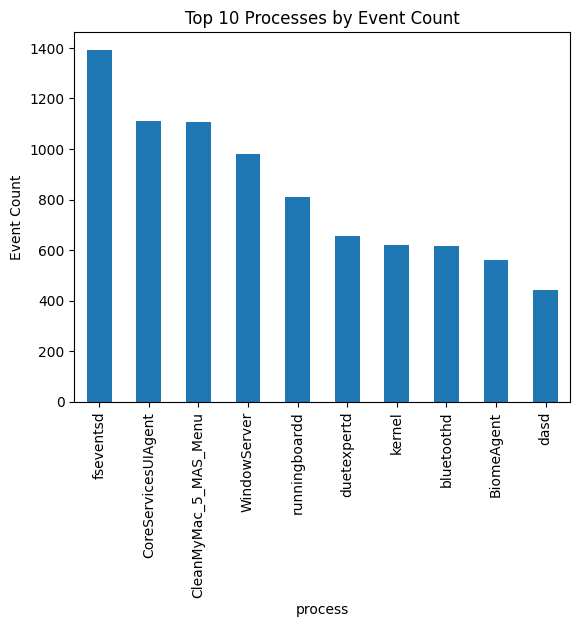

In [6]:
process_counts.head(10).plot(kind='bar')
plt.title("Top 10 Processes by Event Count")
plt.ylabel("Event Count")
plt.show()

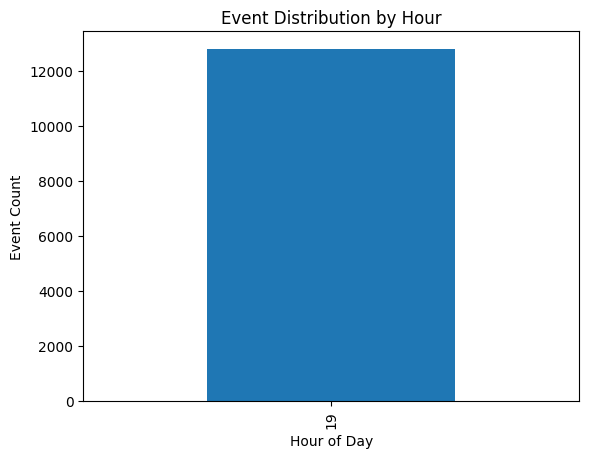

In [7]:
hour_counts = df['hour'].value_counts().sort_index()

hour_counts.plot(kind='bar')
plt.title("Event Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Event Count")
plt.show()

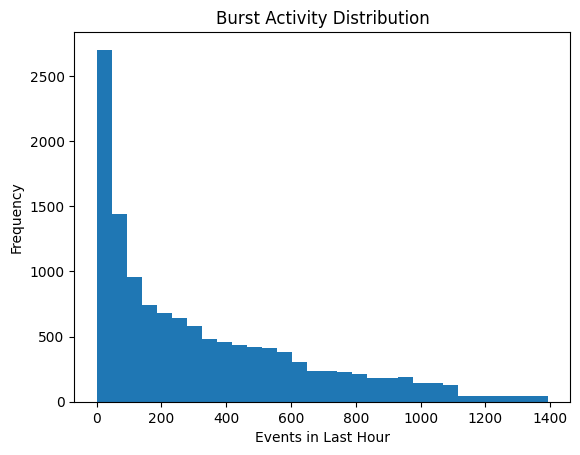

In [8]:
plt.hist(df['count_last_hour'], bins=30)
plt.title("Burst Activity Distribution")
plt.xlabel("Events in Last Hour")
plt.ylabel("Frequency")
plt.show()

In [9]:
from scipy.stats import zscore

df['burst_zscore'] = zscore(df['count_last_hour'])

df[df['burst_zscore'] > 2][
    ['timestamp','process','type','count_last_hour','burst_zscore']
].head(10)

,timestamp,process,type,count_last_hour,burst_zscore
2176,2026-06-22 19:00:51.765654+00:00,CleanMyMac_5_MAS_Menu,Activity,971.0,2.002969
2177,2026-06-22 19:00:51.765832+00:00,CleanMyMac_5_MAS_Menu,Activity,972.0,2.006087
2178,2026-06-22 19:00:51.766021+00:00,CleanMyMac_5_MAS_Menu,Activity,973.0,2.009204
2179,2026-06-22 19:00:51.766201+00:00,CleanMyMac_5_MAS_Menu,Activity,974.0,2.012321
2180,2026-06-22 19:00:51.766376+00:00,CleanMyMac_5_MAS_Menu,Activity,975.0,2.015438
2181,2026-06-22 19:00:51.766553+00:00,CleanMyMac_5_MAS_Menu,Activity,976.0,2.018555
2182,2026-06-22 19:00:51.766740+00:00,CleanMyMac_5_MAS_Menu,Activity,977.0,2.021672
2183,2026-06-22 19:00:51.766924+00:00,CleanMyMac_5_MAS_Menu,Activity,978.0,2.024789
2184,2026-06-22 19:00:51.767111+00:00,CleanMyMac_5_MAS_Menu,Activity,979.0,2.027906
2185,2026-06-22 19:00:51.767292+00:00,CleanMyMac_5_MAS_Menu,Activity,980.0,2.031023


In [10]:
df['suspicious_proxy'] = (
    (df['off_hours'] == 1) |
    (df['rare_process'] == 1) |
    (df['security_related'] == 1) |
    (df['is_error'] == 1) |
    (df['is_fault'] == 1) |
    (df['burst_zscore'] > 2)
).astype(int)

In [11]:
P_suspicious = df['suspicious_proxy'].mean()
P_normal = 1 - P_suspicious

P_suspicious, P_normal

(np.float64(0.08422533010391436), np.float64(0.9157746698960856))

In [12]:
bayes_features = [
    'off_hours',
    'rare_process',
    'first_seen',
    'security_related',
    'is_error',
    'is_fault'
]

P_feature_given_susp = df[df['suspicious_proxy'] == 1][bayes_features].mean()
P_feature_given_susp

off_hours           0.000000
rare_process        0.010204
first_seen          0.012987
security_related    0.212430
is_error            0.119666
is_fault            0.002783
dtype: float64

In [13]:
P_feature_given_normal = df[df['suspicious_proxy'] == 0][bayes_features].mean()
P_feature_given_normal

off_hours           0.000000
rare_process        0.000000
first_seen          0.008873
security_related    0.000000
is_error            0.000000
is_fault            0.000000
dtype: float64

In [14]:
def feature_likelihood(row, probabilities):
    likelihood = 1.0

    for feature in bayes_features:
        probability = probabilities[feature]
        likelihood *= probability if row[feature] else 1 - probability

    return likelihood


def bayes_score(row):
    likelihood_s = P_suspicious * feature_likelihood(row, P_feature_given_susp)
    likelihood_n = P_normal * feature_likelihood(row, P_feature_given_normal)
    total = likelihood_s + likelihood_n

    return likelihood_s / total if total else 0


df['bayes_risk_score'] = df.apply(bayes_score, axis=1)

In [15]:
df.sort_values('bayes_risk_score', ascending=False)[
    ['timestamp','process','type','message','bayes_risk_score','off_hours','rare_process','security_related','is_error','is_fault']
].head(10)

,timestamp,process,type,message,bayes_risk_score,off_hours,rare_process,security_related,is_error,is_fault
2457,2026-06-22 19:01:17.669358+00:00,ContextStoreAgent,Activity,SecKeyVerifySignature,1.0,0,0,1,0,0
2432,2026-06-22 19:00:50.884911+00:00,ContextStoreAgent,Error,Simulating crash. Reason: <private>,1.0,0,0,0,1,0
2410,2026-06-22 19:00:49.593313+00:00,ContextStoreAgent,Activity,SecTrustEvaluateIfNecessary,1.0,0,0,1,0,0
5041,2026-06-22 19:00:51.268025+00:00,WindowServer,Error,transaction 140757 timed out,1.0,0,0,0,1,0
2415,2026-06-22 19:00:49.602483+00:00,ContextStoreAgent,Error,Simulating crash. Reason: <private>,1.0,0,0,0,1,0
2416,2026-06-22 19:00:49.602516+00:00,ContextStoreAgent,Error,Simulating crash. Reason: <private>,1.0,0,0,0,1,0
10138,2026-06-22 19:00:53.347925+00:00,kernel,Error,SID: 0x0 task: <private> buffer: 0x0 buffer->...,1.0,0,0,0,1,0
2423,2026-06-22 19:00:50.856880+00:00,ContextStoreAgent,Activity,SecKeyVerifySignature,1.0,0,0,1,0,0
2424,2026-06-22 19:00:50.857373+00:00,ContextStoreAgent,Activity,SecKeyVerifySignature,1.0,0,0,1,0,0
2425,2026-06-22 19:00:50.857653+00:00,ContextStoreAgent,Activity,SecTrustEvaluateIfNecessary,1.0,0,0,1,0,0


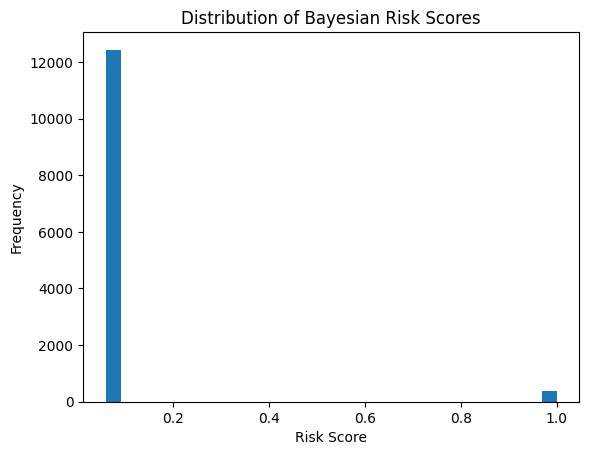

In [16]:
import matplotlib.pyplot as plt

plt.hist(df['bayes_risk_score'], bins=30)
plt.title("Distribution of Bayesian Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

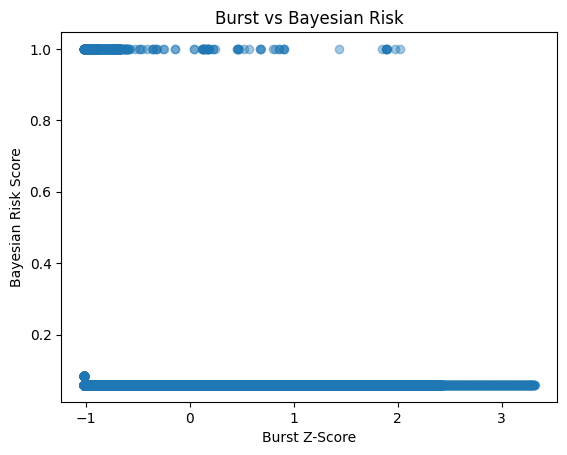

In [17]:
plt.scatter(df['burst_zscore'], df['bayes_risk_score'], alpha=0.4)
plt.xlabel("Burst Z-Score")
plt.ylabel("Bayesian Risk Score")
plt.title("Burst vs Bayesian Risk")
plt.show()

In [18]:
threshold = df['bayes_risk_score'].quantile(0.99)

high_risk = df[df['bayes_risk_score'] >= threshold]

high_risk[['timestamp','process','type','message','bayes_risk_score','off_hours','burst_zscore']].head(20)

,timestamp,process,type,message,bayes_risk_score,off_hours,burst_zscore
33,2026-06-22 19:00:21.699233+00:00,AMPLibraryAgent,Error,AMSURLRequestDecoration: Skipping GUID parame...,1.0,0,-0.923979
35,2026-06-22 19:00:21.699339+00:00,AMPLibraryAgent,Error,AMSURLRequestDecoration: Skipping add payment...,1.0,0,-0.917744
86,2026-06-22 19:00:21.737663+00:00,AMPLibraryAgent,Activity,SecKeyCopyPublicBytes,1.0,0,-0.758773
89,2026-06-22 19:00:21.738177+00:00,AMPLibraryAgent,Default,"No pending evals, starting",1.0,0,-0.749421
90,2026-06-22 19:00:21.738255+00:00,AMPLibraryAgent,Activity,SecTrustEvaluateIfNecessaryFastAsync,1.0,0,-0.746304
91,2026-06-22 19:00:21.738370+00:00,AMPLibraryAgent,Default,Completed async eval kickoff,1.0,0,-0.743187
92,2026-06-22 19:00:21.753574+00:00,AMPLibraryAgent,Default,trustd returned 4,1.0,0,-0.740070
101,2026-06-22 19:00:21.753763+00:00,AMPLibraryAgent,Activity,SecKeyCopyPublicBytes,1.0,0,-0.712016
102,2026-06-22 19:00:21.753835+00:00,AMPLibraryAgent,Activity,SecKeyCopyPublicBytes,1.0,0,-0.708899
107,2026-06-22 19:00:21.754067+00:00,AMPLibraryAgent,Activity,SecKeyCopyPublicBytes,1.0,0,-0.693314
